<a href="https://colab.research.google.com/github/MassGH2023/Deep-Learning-and-Neural-Network/blob/main/TF_mnist_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

#tf.logging.set_verbosity(tf.logging.ERROR)
print('Using TensorFlow version', tf.__version__)

Using TensorFlow version 2.18.0


In [3]:
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)


# MNIST dataset

In [7]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [9]:
(X_train.shape, y_train.shape), (X_test.shape, y_test.shape)

(((60000, 28, 28), (60000,)), ((10000, 28, 28), (10000,)))

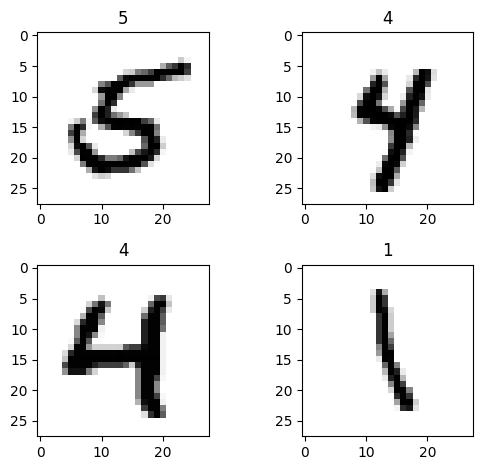

In [25]:
import matplotlib.pyplot as plt
import random
%matplotlib inline
ii = [random.randint(0, 60000) for _ in range(4)]
f, a = plt.subplots(2,2)
for i, idx in enumerate(ii):
  ax = a[i//2, i%2]
  ax.imshow(X_train[idx], cmap = 'binary')
  ax.set_title(y_train[idx])
  plt.tight_layout()

In [32]:
for i, idx in enumerate(ii):
  print((i, idx))
  print((i//2, i%2))

(0, 51027)
(0, 0)
(1, 10845)
(0, 1)
(2, 17390)
(1, 0)
(3, 38806)
(1, 1)


# One Hot Encoding


| original label | one-hot encoded label |
|------|------|
| 5 | [0, 0, 0, 0, 0, 1, 0, 0, 0, 0] |
| 7 | [0, 0, 0, 0, 0, 0, 0, 1, 0, 0] |
| 1 | [0, 1, 0, 0, 0, 0, 0, 0, 0, 0] |


In [33]:
from tensorflow.keras.utils import to_categorical
y_train_encoded = to_categorical(y_train)
y_test_encoded = to_categorical(y_test)

In [35]:
y_train_encoded[:4]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [40]:
print(f"the shapes after encoding is {y_train_encoded.shape} and {y_test_encoded.shape}")

the shapes after encoding is (60000, 10) and (10000, 10)


In [43]:
type(y_test_encoded), type(X_test)

(numpy.ndarray, numpy.ndarray)

In [45]:
import numpy as np

X_train_reshaped = np.reshape(X_train, (60000, 784))
X_test_reshaped = np.reshape(X_test, (X_test.shape[0], -1))


In [46]:
X_train_reshaped.shape, X_test_reshaped.shape

((60000, 784), (10000, 784))

# normalization

In [49]:
x_mean = np.mean(X_train_reshaped)
x_std = np.std(X_train_reshaped)


In [50]:
x_mean, x_std

(33.318421449829934, 78.56748998339798)

In [51]:
epsilon = 1e-10
X_train_norm = (X_train_reshaped - x_mean) /(x_std + epsilon)

X_test_norm = (X_test_reshaped - x_mean) /(x_std + epsilon)
